# **Analyze Semantic Change (Ngrams)**
## **Goal**: Use trained `Word2vec` embeddings to examine semantic change over time.

### **Imports**

In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from ngramprep.common.w2v_model import W2VModel
from analyze.cosine_similarity_time_series import cosine_similarity_over_years, plot_nearest_neighbors
from analyze.weat_time_series import compute_weat_over_years
from analyze.dimension_projection_time_series import compute_projection_over_years, compute_baseline_set
from analyze.pca_dimension_time_series import compute_pca_dimension_over_years
from analyze.semantic_drift import track_local_semantic_change, track_global_semantic_change, track_directional_drift
from analyze.average_relatedness_by_year import track_word_relatedness

The `ngram-kit` package contains several tools useful in quantifying how much word meanings have changed over the years. Before using these tools, it helps to set a model path variable. Most commonly, this will point to the `norm_and_align` directory. We'll also set a `corpus_path` variable pointing to the yearly corpus data.

In [2]:
model_path =  '/scratch/edk202/NLP_models/Google_Books/20200217/rus/5gram_files/models_final/norm_and_align'

### `compare_words_cosim` method

Let's say we want to measure the relationship between three pairs of words — _horse_ and _donkey_, _horse_ and _lizard_ , and _horse_ and _amoeba_ — in the 2019 corpus. We first create a `W2VModel` instance for the 2019 embeddings. Then, we call the `compare_words_cosim` method for our words.

In [3]:
year = 2010
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

word1, word2 = 'лошадь', 'кобыла'
similarity = model.compare_words_cosim(word1, word2)
print(f"cos(Φ) of \'{word1}\' and \'{word2}\' in {year} = {similarity:.4f}")

word1, word2 = 'лошадь', 'олень'
similarity = model.compare_words_cosim(word1, word2)
print(f"cos(Φ) of \'{word1}\' and \'{word2}\' in {year} = {similarity:.4f}")

word1, word2 = 'лошадь', 'утка'
similarity = model.compare_words_cosim(word1, word2)
print(f"cos(Φ) of \'{word1}\' and \'{word2}\' in {year} = {similarity:.4f}")

word1, word2 = 'лошадь', 'атом'
similarity = model.compare_words_cosim(word1, word2)
print(f"cos(Φ) of \'{word1}\' and \'{word2}\' in {year} = {similarity:.4f}")

cos(Φ) of 'лошадь' and 'кобыла' in 2010 = 0.3762
cos(Φ) of 'лошадь' and 'олень' in 2010 = 0.3569
cos(Φ) of 'лошадь' and 'утка' in 2010 = 0.2911
cos(Φ) of 'лошадь' and 'атом' in 2010 = 0.1128


The results are about what you'd expect!

### `compare_models_cosim` method
Suppose we want to compare the semantic similarity of the _same_ words across _models_. We can use the `compare_models_cosim` method to compute the average cosine similarity between shared words in two models. Or, if we specify the `word` parameter, we can compute similarity for a single word across the models.

In [4]:
year = 2010
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')
reference_model = W2VModel(f'{model_path}/w2v_y2000_wbnone_vs300_w004_mc001_sg1_e010.kv')

cosim_mean, cosim_sd, shared_words = model.compare_models_cosim(reference_model)
print(f"Overall similarity between models:\n  cos(Φ) mean = {cosim_mean:.4f}\n  cos(Φ) SD = {cosim_sd:.4f}\n  shared words: {shared_words}\n")

word = 'гей'
cosim, _, _ = model.compare_models_cosim(reference_model, word)
print(f"Similarity of \'{word}\' between models:\n  cos(Φ) = {cosim:.4f}\n")

Overall similarity between models:
  cos(Φ) mean = 0.8521
  cos(Φ) SD = 0.0680
  shared words: 19160

Similarity of 'гей' between models:
  cos(Φ) = 0.9567



### `mean_cosine_similarity_to_all` method

In [5]:
year = 2010
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

mean_sim = model.mean_cosine_similarity_to_all('мужчина', '')

print(f"Mean cosine similarity = {mean_sim:.4f}")

Mean cosine similarity = 0.2177


### `track_local_semantic_change` function

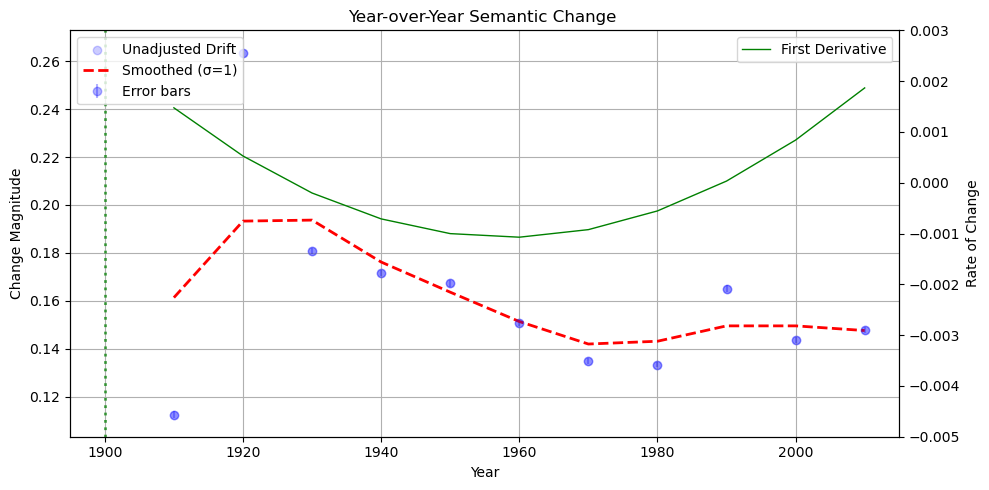

In [6]:
drift_scores = track_local_semantic_change(
    start_year=1900,
    end_year=2010,
    year_step=10,
    model_dir=model_path,
    plot=True,
    error_type='CI',
    smooth=True,
    sigma=1,
    confidence=0.99
)

### `track_global_semantic_change` function

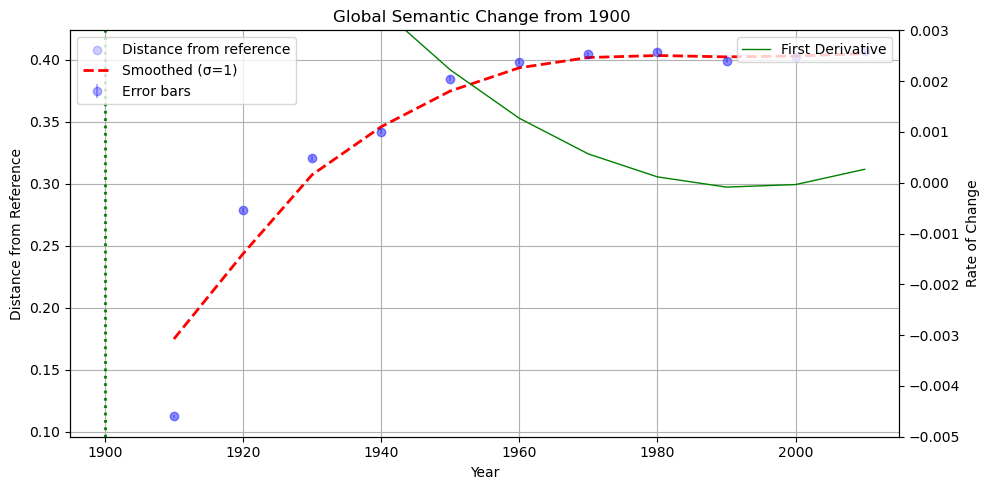

In [7]:
drift_scores = track_global_semantic_change(
    start_year=1900,
    end_year=2010,
    year_step=10,
    model_dir=model_path,
    plot=True,
    error_type='CI',
    smooth=True,
    sigma=1,
    confidence=0.99
)

### `track_word_relatedness` function

The `cosine_similarity_time_series` function uses the `compare_words_cosim` method to track the relationship between a pair of words across time. Simply specify your two words (`word1` and `word2`), a `start_year` and `end_year`, and the model directory. You'll get a list of years and associated cosine similarities; set `plot=True` if you want to graph them. The model will skip any years for which there is no model or there words aren't in the models' shared vocabulary.

Computing mean cosine similarity for 1 words (Excluding: 0 words)
⚠️ No models found for these years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]


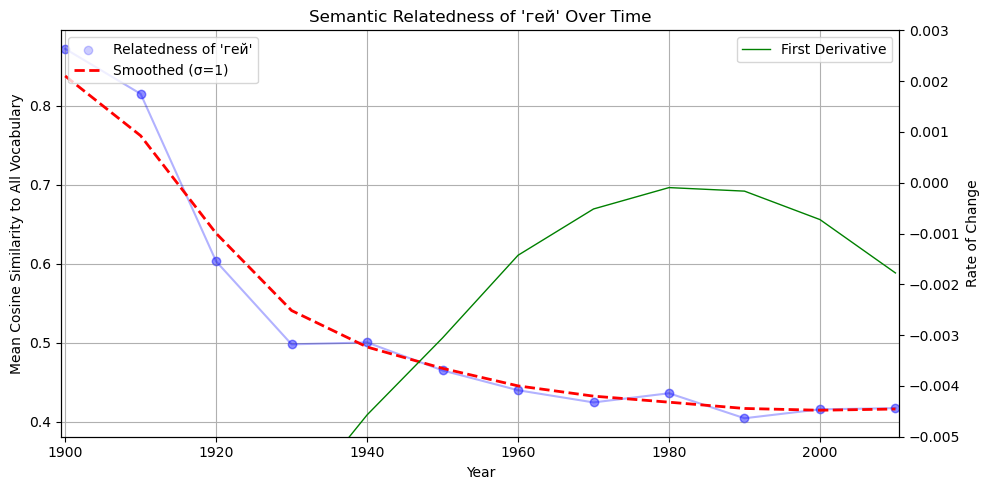

In [8]:
relatedness_scores = track_word_relatedness(
    word=['гей'],
    start_year=1900,
    end_year=2010,
    year_step=1,
    model_dir=model_path,
    plot=1,
    smooth=True,
    sigma=1
)

### `cosine_similarity_over_years` function

The `cosine_similarity_time_series` function uses the `compare_words_cosim` method to track the relationship between a pair of words across time. Simply specify your two words (`word1` and `word2`), a `start_year` and `end_year`, and the model directory. You'll get a list of years and associated cosine similarities; set `plot=True` if you want to graph them. The model will skip any years for which there is no model or there words aren't in the models' shared vocabulary.


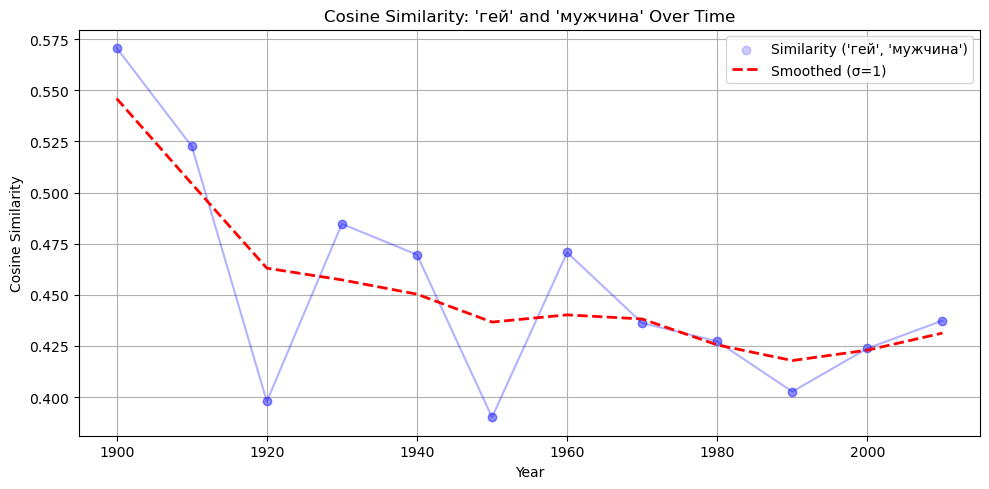

In [9]:
sim_scores = cosine_similarity_over_years(
    word1=['гей'],
    word2=['мужчина'],
    start_year=1900,
    end_year=2010,
    year_step=10,
    plot_derivative=False,
    model_dir=model_path,
    plot=1,
    smooth=True,
    sigma=1
)

### `track_directional_drift` function

Loading embeddings for word 'гей' across 12 years...
⚠️ No models found for these years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]


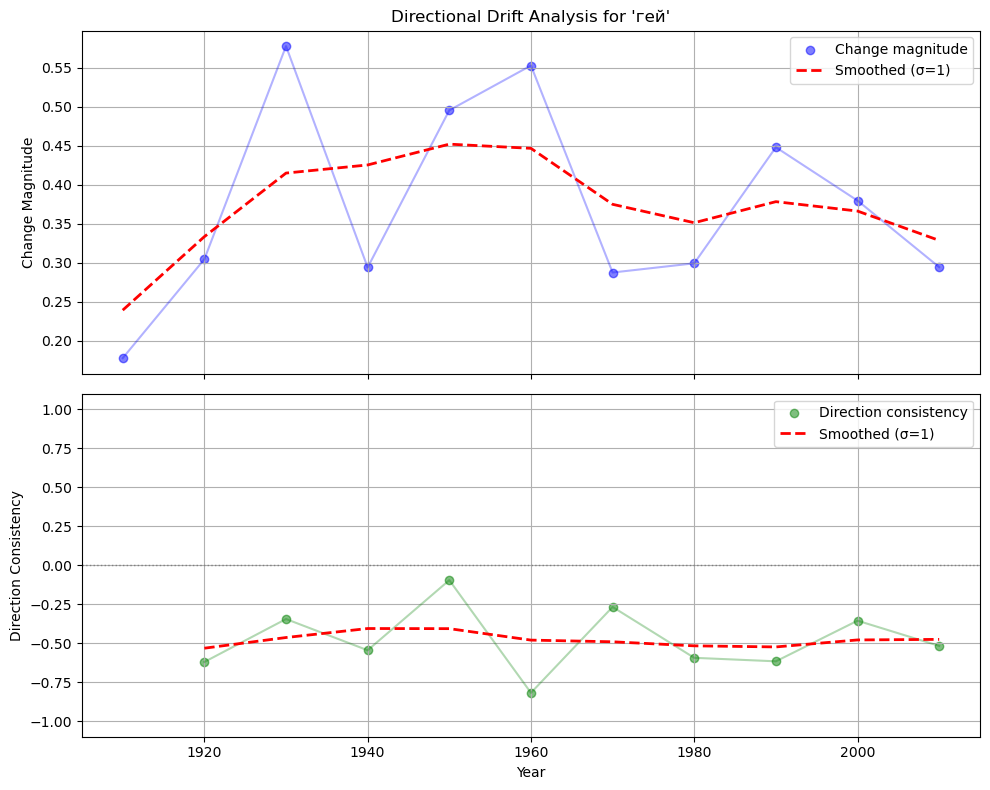

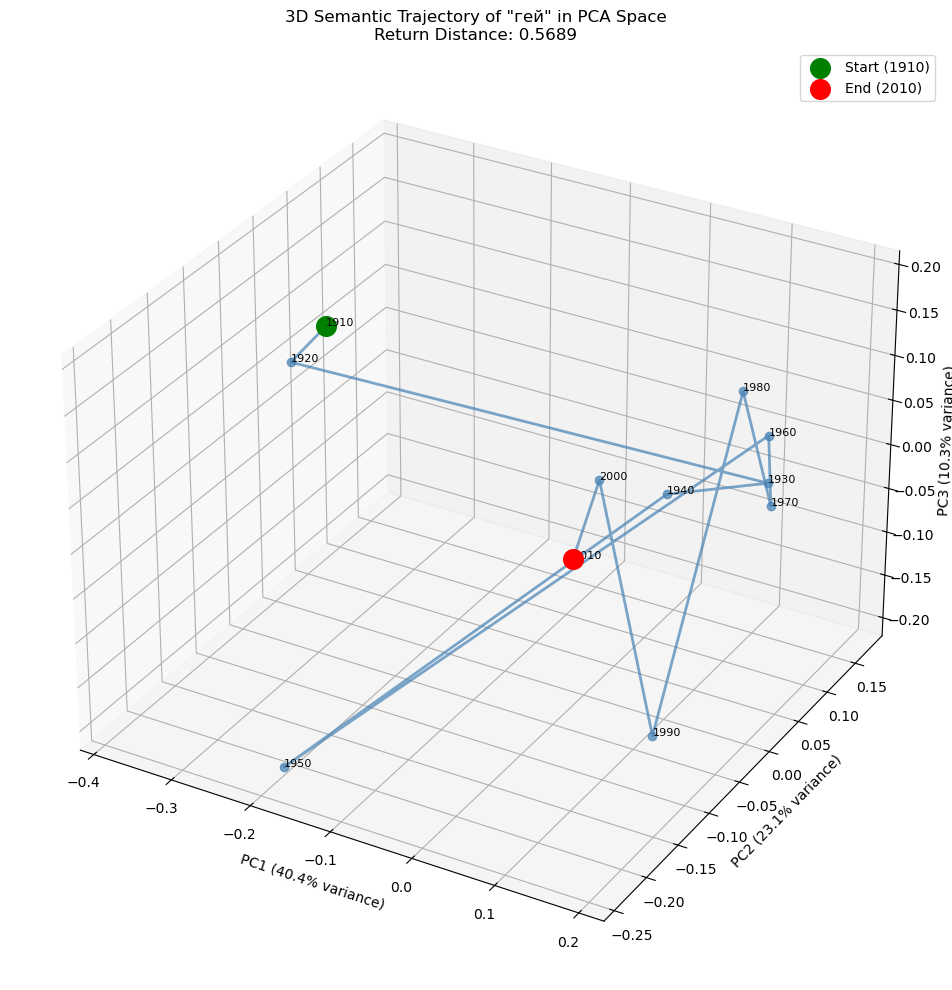

In [10]:
drift_scores = track_directional_drift(
    word='гей',
    start_year=1900,
    end_year=2010,
    year_step=1,
    model_dir=model_path,
    plot=True,
    smooth=True,
    sigma=1,
    plot_trajectory=True,
    trajectory_3d=True
)

### `plot_nearest_neighbors` function

This function plots the N nearest neighbors to a target word for a specific year, showing their cosine similarity scores in a horizontal bar chart.

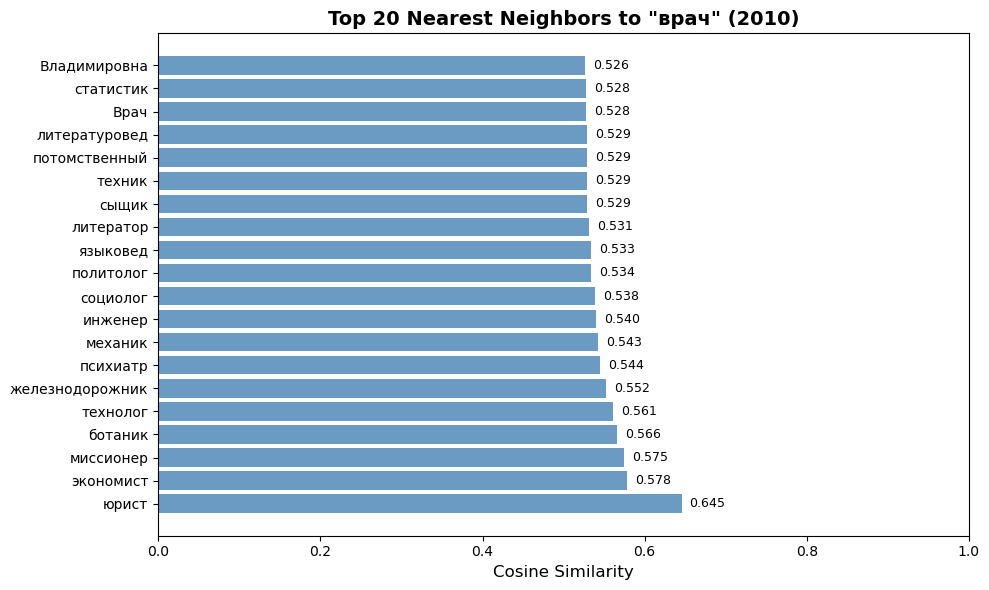

In [11]:
neighbors = plot_nearest_neighbors(
    word='врач',
    year=2010,
    model_dir=model_path,
    n=20
)

### `compute_weat` method
This method runs a Word Embedding Association Test (WEAT) as described in [Caliskan, Bryson, and Narayanan, 2017](https://www.science.org/doi/10.1126/science.aal4230). The WEAT is a close analog of the Implicit Association Test (IAT; [Greenwald, McGhee, & Schwarz, 1995](https://psycnet.apa.org/record/1998-02892-004))—but, whereas the IAT uses reaction latencies to measure a person's cognitive association between two mental category constrasts, the WEAT uses cosine similarities to measure the semantic association between linguistic category contrasts in a corpus.

Just as with the IAT, the WEAT requires that you select two constrasting "target" categories (e.g., _man_ vs. _woman_) and two contrasting "attribute" categories (e.g., _science_ vs. _art_), as well as a list of exemplars of each of these four categories. The `compute_weat` method then:
1. calculates the mean of all pairwise cosine similarities among exemplars within each target–attribute combination (e.g., $\bar c_{man, science}$, $\bar c_{man, art}$, $\bar c_{woman, science}$, $\bar c_{woman, art}$),
2. takes the difference in mean similarity between combinations involving the same target (e.g., $\bar c_{man, science} - \bar c_{man, art}$ and $\bar c_{woman, science} - \bar c_{woman, art}$),
3. subtracts these differences from one another (e.g., $[(\bar c_{man, science} - \bar c_{man, art}) - (\bar c_{woman, science} - \bar c_{woman, art})]$), and
4. divides this difference by the pooled standard deviation across all exemplars for all target–attribute pairs.

This calculation yields an effect size, $d$, analogous to that used in IAT research. Higher scores indicate a stronger relative semantic link between the first target and first attribute (e.g., between _man_ and _science_).

In [12]:
model = W2VModel(f'{model_path}/w2v_y2000_wbnone_vs300_w004_mc001_sg1_e010.kv')

target1 = ["brad", "brendan", "geoffrey", "greg", "brett", "jay", "matthew", "neil", "todd", "allison", "anne", "carrie", "emily", "jill", "laurie", "kristen", "meredith", "sarah"]
target2 = ["darnell", "hakim", "jermaine", "kareem", "jamal", "leroy", "rasheed", "tremayne", "tyrone", "ebony", "kenya"]
attribute1 = ["joy", "love", "peace", "wonderful", "pleasure", "friend", "laughter", "happy"]
attribute2 = ["agony", "terrible", "horrible", "nasty", "evil", "war", "awful", "failure"]

weat_score, p = model.compute_weat(
    target1,
    target2,
    attribute1,
    attribute2,
    num_permutations=1_000
)

print(f"WEAT effect size (Cohen's d) = {weat_score:.4f}, p = {p:.4f}")

⚠️ Warning: The following words are missing from the model and will be ignored: ['brad', 'brendan', 'geoffrey', 'greg', 'brett', 'jay', 'matthew', 'neil', 'todd', 'allison', 'anne', 'carrie', 'emily', 'jill', 'laurie', 'kristen', 'meredith', 'sarah', 'darnell', 'hakim', 'jermaine', 'kareem', 'jamal', 'leroy', 'rasheed', 'tremayne', 'tyrone', 'ebony', 'kenya', 'joy', 'love', 'peace', 'wonderful', 'pleasure', 'friend', 'laughter', 'happy', 'agony', 'terrible', 'horrible', 'nasty', 'evil', 'war', 'awful', 'failure']
WEAT effect size (Cohen's d) = nan, p = 0.0000


/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


⚠️ Warning: The following words are missing from the model and will be ignored: ['doctor', 'nurse', 'female', 'she', 'her', 'hers', 'herself', 'woman', 'women', 'girl', 'girls', 'mother', 'mothers', 'daughter', 'daughters', 'sister', 'sisters', 'male', 'he', 'him', 'his', 'himself', 'man', 'men', 'boy', 'boys', 'son', 'sons', 'brother', 'brothers']
⚠️ Warning: The following words are missing from the model and will be ignored: ['doctor', 'nurse', 'female', 'she', 'her', 'hers', 'herself', 'woman', 'women', 'girl', 'girls', 'mother', 'mothers', 'daughter', 'daughters', 'sister', 'sisters', 'male', 'he', 'him', 'his', 'himself', 'man', 'men', 'boy', 'boys', 'son', 'sons', 'brother', 'brothers']
⚠️ Warning: The following words are missing from the model and will be ignored: ['doctor', 'nurse', 'female', 'she', 'her', 'hers', 'herself', 'woman', 'women', 'girl', 'girls', 'mother', 'mothers', 'daughter', 'daughters', 'sister', 'sisters', 'male', 'he', 'him', 'his', 'himself', 'man', 'men', 

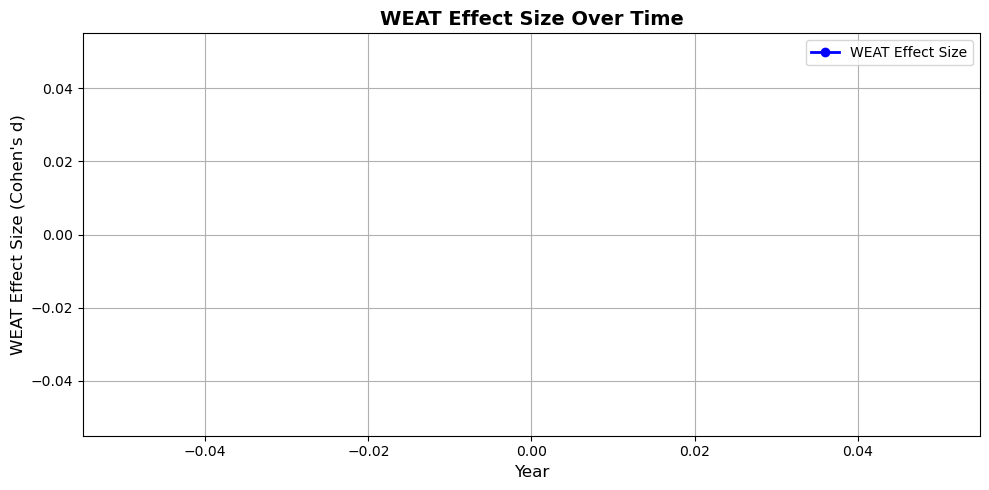

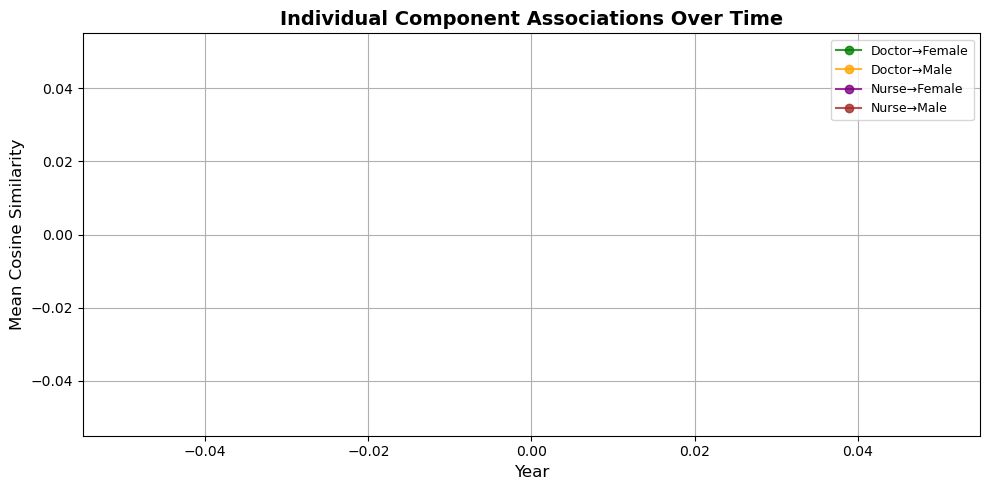

In [13]:
target1 = {'Doctor': ["doctor"]}
target2 = {'Nurse': ["nurse"]}
attribute1 = {'Female': ["female", "she", "her", "hers", "herself", "woman", "women", "girl", "girls", "mother", "mothers", "daughter", "daughters", "sister", "sisters"]}
attribute2 = {'Male': ["male", "he", "him", "his", "himself", "man", "men", "boy", "boys", "son", "sons", "brother", "brothers"]}

weat_scores = compute_weat_over_years(
    target1,
    target2,
    attribute1,
    attribute2,
    start_year=1900,
    end_year=2019,
    year_step=1,
    model_dir=f"{model_path}",
    num_permutations=0,
    plot=1,
    smooth=False,
    sigma=1,
    return_std=False,
    return_associations=True,
    plot_associations=['Doctor→Male', 'Nurse→Female', 'Doctor→Female', 'Nurse→Male']
)

### `compute_meandiff_dimension` method

In [14]:
year = 1900
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('она', 'он'),
    ('её', 'его'),
    ('сама', 'сам'),
    ('женщина', 'мужчина'),
    ('женщины', 'мужчины'),
    ('девочка', 'мальчик'),
    ('девочки', 'мальчики'),
    ('мать', 'отец'),
    ('матери', 'отцы'),
    ('дочь', 'сын'),
    ('дочери', 'сыновья'),
    ('сестра', 'брат'),
    ('сёстры', 'братья')
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

W2VModel.print_meandiff_summary(meandiff_result)
W2VModel.print_component_loadings(meandiff_result, title="COMPONENT LOADINGS")

⚠️ Warning: The following pairs contain words not in vocabulary and will be skipped:
  ('её', 'его')
  ('сёстры', 'братья')

════════════════════════════════════════════════════════════════════════════════════════════════════
MEAN-DIFFERENCE DIMENSION SUMMARY
════════════════════════════════════════════════════════════════════════════════════════════════════
Valid pairs:             11

Pair Loading Statistics:
────────────────────────────────────────────────────────────────────────────────────────────────────
Mean loading:                          0.4974
Std deviation:                         0.1946
Min loading:                           0.0797
Max loading:                           0.7235
Loading range:                         0.6438
Coeff. of variation:                   0.3913

────────────────────────────────────────────────────────────────────────────────────────────────────
Pair Coherence:          MODERATE (mixed semantic domains)
───────────────────────────────────────────────

### `print_word_projections` method

In [15]:
year = 2010
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('она', 'он'),
    ('её', 'его'),
    ('сама', 'сам'),
    ('женщина', 'мужчина'),
    ('женщины', 'мужчины'),
    ('девочка', 'мальчик'),
    ('девочки', 'мальчики'),
    ('мать', 'отец'),
    ('матери', 'отцы'),
    ('дочь', 'сын'),
    ('дочери', 'сыновья'),
    ('сестра', 'брат'),
    ('сёстры', 'братья')
]

test_words = [
    'она', 'он', 'женщина', 'мужчина', 'женский', 'мужской', 'девочка', 'мальчик',
    'мать', 'отец', 'дочь', 'сын', 'сестра', 'брат',
    'королева', 'король', 'актриса', 'актёр', 'официантка', 'официант',
    'хирург', 'врач', 'медсестра', 'учитель', 'инженер', 'учёный',
    'юрист', 'лидер', 'помощник', 'начальник', 'секретарь', 'родитель',
    'супруг', 'партнёр', 'председатель', 'официант', 'пожарный', 'физик',
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

projections = W2VModel.print_word_projections(model, meandiff_result['dimension'], test_words)

⚠️ Warning: The following pairs contain words not in vocabulary and will be skipped:
  ('её', 'его')
  ('сёстры', 'братья')

────────────────────────────────────────────────────────────────────────────────────────────────────
WORD PROJECTIONS ON DIMENSION
────────────────────────────────────────────────────────────────────────────────────────────────────
Word                           Projection                                           Visualization
────────────────────────────────────────────────────────────────────────────────────────────────────
  сын                              0.2794                                            ████████
  отец                             0.2632                                             ███████
  брат                             0.2509                                             ███████
  помощник                         0.2134                                              ██████
  мальчик                          0.1814                           

### `compute_projection_over_years` function

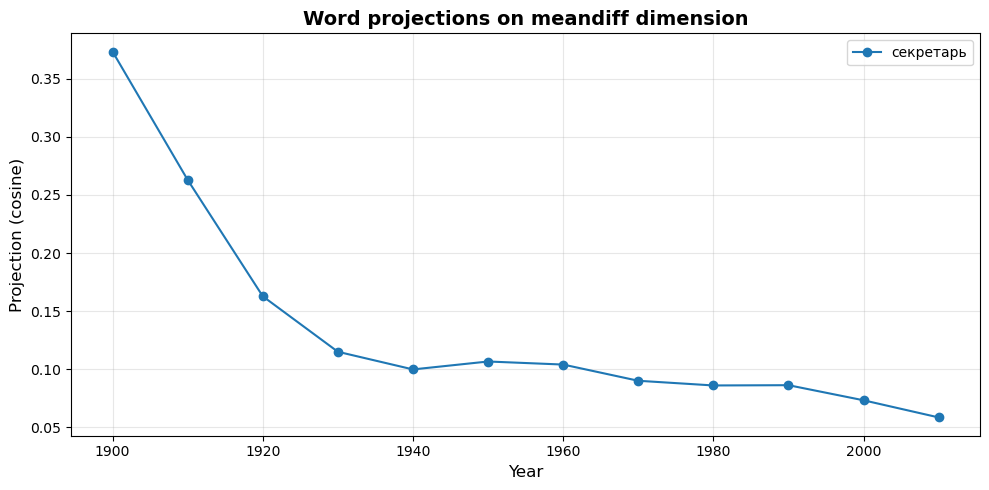

In [16]:
gender_contrasts = [
    ('она', 'он'),
    ('сама', 'сам'),
    ('женщина', 'мужчина'),
    ('женщины', 'мужчины'),
    ('девочка', 'мальчик'),
    ('девочки', 'мальчики'),
    ('мать', 'отец'),
    ('матери', 'отцы'),
    ('дочь', 'сын'),
    ('дочери', 'сыновья'),
    ('сестра', 'брат'),
]

result = compute_projection_over_years(
    model_dir=f"{model_path}",
    token_contrasts=gender_contrasts,
    test_words=['секретарь'],
    start_year=1900,
    end_year=2010,
    year_step=10,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=True,
    sigma=1,
    verbose=False
)

Using shared vocabulary: 17513 words found across all models

Baseline word set selection:
  Total vocabulary:          17,513
  Neutral candidates:        17,386 (after anchor & pattern exclusion)
  Selected neutral words:    11,494 (passed stability thresholds)

  Selection thresholds:
    |mu| < 0.080  (mean projection)
    |beta| < 0.0100  (trend/year)
    sigma < 0.150  (temporal variability)
    n >= 5  (minimum years)

  Neutral word statistics:
    Mean |mu|:     0.0379
    Mean |beta|:   0.0008
    Mean sigma:    0.0538

  Over-time correlation:
    Mean:          0.4737
    Median:        0.5247
    Std:           0.2369
    Range:         [0.0958, 0.8096]

  Aggregation:               mean



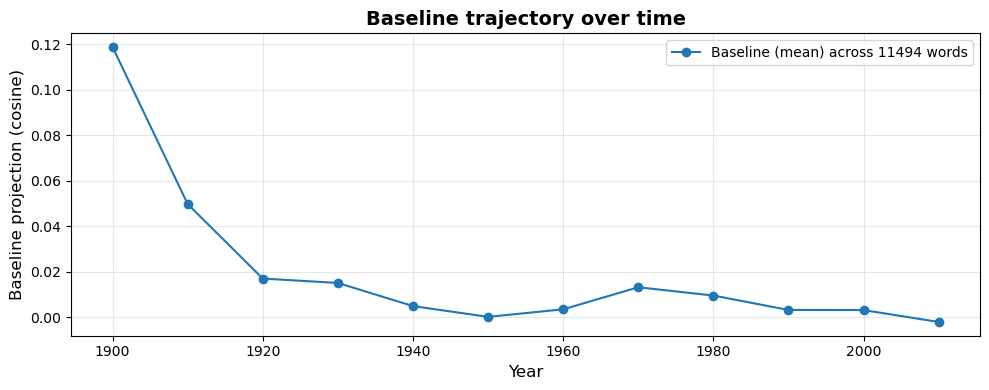

In [17]:
gender_contrasts = [
    ('она', 'он'),
    ('сама', 'сам'),
    ('женщина', 'мужчина'),
    ('женщины', 'мужчины'),
    ('девочка', 'мальчик'),
    ('девочки', 'мальчики'),
    ('мать', 'отец'),
    ('матери', 'отцы'),
    ('дочь', 'сын'),
    ('дочери', 'сыновья'),
    ('сестра', 'брат'),
]

baseline_result = compute_baseline_set(
    model_dir=model_path,
    contrast_pairs=gender_contrasts,
    start_year=1900,
    end_year=2019,
    year_step=1,
    method='meandiff',
    exclusion_pattern=r"(мужчина|мужчины|женщина|женщины|девочка|мальчик|девочки|мальчики|мать|отец|матери|отцы|дочь|сын|дочери|сыновья|сестра|брат)",
    eps_mean=0.08,
    eps_trend=0.010,
    eps_sigma=0.15,
    min_years=5,
    agg="mean",
    corr_n_permutations=0,
    verbose=True,
    plot_baseline=True
)

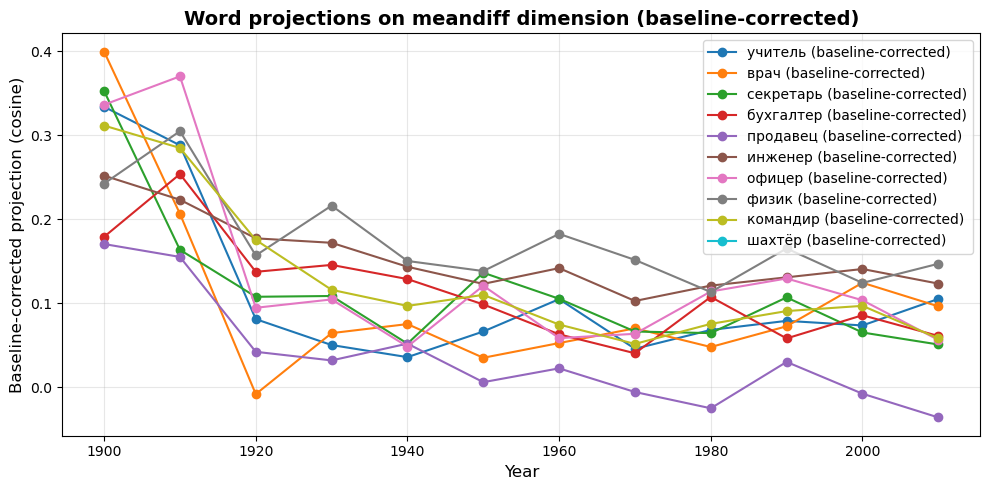

{'dimension': None,
 'reference_year': 1900,
 'method': 'meandiff',
 'projections':        учитель      врач  секретарь  бухгалтер  продавец   инженер    офицер  \
 1900  0.452751  0.518416   0.471534   0.298035  0.289402  0.370827  0.455243   
 1910  0.337958  0.256437   0.213524   0.303719  0.205104  0.273170  0.420005   
 1920  0.098341  0.009103   0.124956   0.154675  0.059474  0.194516  0.111862   
 1930  0.065582  0.079758   0.123947   0.160944  0.047280  0.187269  0.119852   
 1940  0.041024  0.080378   0.057100   0.133953  0.057086  0.148564  0.053577   
 1950  0.066809  0.035538   0.136754   0.099033  0.006495  0.123476  0.121247   
 1960  0.108641  0.056360   0.109050   0.066748  0.026256  0.145541  0.062228   
 1970  0.059244  0.083568   0.079786   0.053897  0.007799  0.116135  0.077063   
 1980  0.078012  0.057718   0.074260   0.117297 -0.015211  0.130791  0.123794   
 1990  0.082505  0.076045   0.110418   0.061612  0.033647  0.134304  0.132937   
 2000  0.076988  0.127800 

In [20]:
gender_contrasts = [
    ('она', 'он'),
    ('сама', 'сам'),
    ('женщина', 'мужчина'),
    ('женщины', 'мужчины'),
    ('девочка', 'мальчик'),
    ('девочки', 'мальчики'),
    ('мать', 'отец'),
    ('матери', 'отцы'),
    ('дочь', 'сын'),
    ('дочери', 'сыновья'),
    ('сестра', 'брат'),
]

try:
    baseline_result
except NameError:
    baseline_result = compute_baseline_set(
        model_dir=model_path,
        contrast_pairs=gender_contrasts,
        start_year=1900,
        end_year=2019,
        year_step=1,
        method='meandiff',
        ensure_sign_positive=True,
        exclusion_pattern=r"(мужчина|мужчины|женщина|женщины|девочка|мальчик|девочки|мальчики|мать|отец|матери|отцы|дочь|сын|дочери|сыновья|сестра|брат)",
        min_years=5,
        agg="median",
        plot=False,
        corr_n_permutations=0,
    )

targets = ['учитель', 'врач', 'секретарь', 'бухгалтер', 'продавец', 'инженер', 'офицер', 'физик', 'командир', 'шахтёр']

compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1900,
    end_year=2010,
    year_step=10,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=False,
    sigma=2,
    verbose=False,
    baseline_result=baseline_result,
    plot_corrected_if_baseline=True,
    plot=True,
 )

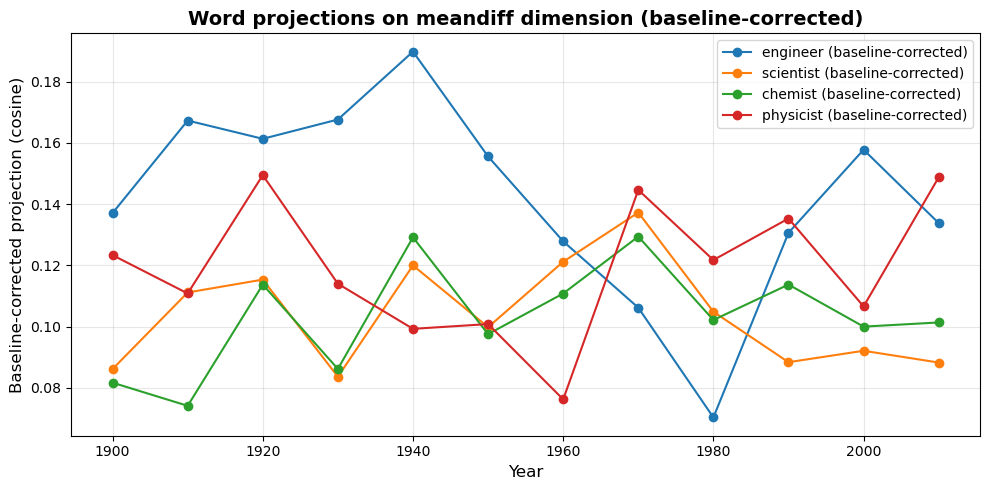

In [38]:
gender_contrasts = [ 
    ('she', 'he'),
    ('her', 'him'),
    ('hers', 'his'),
    ('herself', 'himself'),
    ('woman', 'man'),
    ('women', 'men'),
    ('girl', 'boy'),
    ('girls', 'boys'),
    ('mother', 'father'),
    ('mothers', 'fathers'),
    ('daughter', 'son'),
    ('daughters', 'sons'),
    ('sister', 'brother'),
    ('sisters', 'brothers')
]

baseline_words = [
    'table', 'chair', 'window', 'door', 'wall', 'floor', 'roof',
    'tree', 'leaf', 'branch', 'root', 'flower', 'grass',
    'water', 'stone', 'rock', 'sand', 'soil', 'clay',
    'book', 'page', 'paper', 'pen', 'ink',
    'cup', 'plate', 'bowl', 'spoon', 'knife', 'fork',
    'bread', 'cheese', 'butter', 'salt', 'sugar',
    'road', 'path', 'bridge', 'gate', 'fence',
    'box', 'bag', 'basket', 'bottle', 'jar',
    'horse', 'cow', 'sheep', 'pig', 'chicken', 'dog', 'cat',
    'sun', 'moon', 'star', 'cloud', 'rain', 'wind',
    'river', 'lake', 'mountain', 'hill', 'valley',
    'wood', 'metal', 'iron', 'gold', 'silver',
    'wheel', 'rope', 'chain', 'nail', 'hammer'
]

try:
    baseline_result
except NameError:
    baseline_result = compute_baseline_set(
        model_dir=model_path,
        contrast_pairs=gender_contrasts,
        start_year=1900,
        end_year=2019,
        year_step=1,
        method='meandiff',
        ensure_sign_positive=True,
        exclusion_pattern=r"(man|men|woman|women|girl|boy|wife|husband|mother|father|son|daughter|she|he)",
        min_years=5,
        agg="median",
        plot=False,
        corr_n_permutations=0,
    )

targets = ['engineer', 'scientist', 'chemist', 'physicist']

result = compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1900,
    end_year=2010,
    year_step=10,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=False,
    sigma=1,
    verbose=False,
    baseline_result=baseline_result,
    #baseline_words=baseline_words,
    plot_corrected_if_baseline=True,
    plot=True,
 )